# =========================================
# TRAFFIC CONGESTION PREDICTION - REPORT 4
# =========================================


3. Discussion of Results

Hypothesis:

* H0: Time does not affect traffic
* H1: Time does affect traffic

Based on the model results and feature importance, time variables have a significant influence on the prediction.

*Reject H0, accept H1*

In [8]:
import pandas as pd
import numpy as np
import sqlite3
conn = sqlite3.connect(r"C:\Users\Admin\Desktop\3\ADY201m\data\clean\data_traffic_clean.db")
df = pd.read_sql("SELECT * FROM traffic_data_clean", conn)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head()

Shape: (41221, 8)

Columns: ['id', 'timestamp', 'location', 'current_speed_kmh', 'free_flow_speed_kmh', 'speed_ratio', 'traffic_level', 'confidence']


,id,timestamp,location,current_speed_kmh,free_flow_speed_kmh,speed_ratio,traffic_level,confidence
0,1,2026-01-12 20:19:56,1,53.0,53.0,1.00,THOANG,1.000000
1,2,2026-01-12 20:19:56,2,39.0,49.0,0.80,DONG,0.990786
2,3,2026-01-12 20:19:56,3,29.0,38.0,0.76,DONG,0.914126
3,4,2026-01-12 20:19:56,4,29.0,39.0,0.74,DONG,0.940000
4,5,2026-01-12 20:19:56,5,30.0,39.0,0.77,DONG,0.928320


In [9]:
from sklearn.preprocessing import LabelEncoder

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Encode
le_target = LabelEncoder()
df['traffic_level'] = le_target.fit_transform(df['traffic_level'])

# Feature Engineering
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if 7<=x<=9 or 17<=x<=19 else 0)

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Target
y = df['traffic_level']

# Features (time-based only)
X = df[['location', 'hour_sin', 'hour_cos', 'is_peak_hour', 'day_of_week']]

df.head()

,id,timestamp,location,current_speed_kmh,free_flow_speed_kmh,speed_ratio,traffic_level,confidence,hour,day_of_week,is_peak_hour,hour_sin,hour_cos
0,1,2026-01-12 20:19:56,1,53.0,53.0,1.00,2,1.000000,20,0,0,-0.866025,0.5
1,2,2026-01-12 20:19:56,2,39.0,49.0,0.80,0,0.990786,20,0,0,-0.866025,0.5
2,3,2026-01-12 20:19:56,3,29.0,38.0,0.76,0,0.914126,20,0,0,-0.866025,0.5
3,4,2026-01-12 20:19:56,4,29.0,39.0,0.74,0,0.940000,20,0,0,-0.866025,0.5
4,5,2026-01-12 20:19:56,5,30.0,39.0,0.77,0,0.928320,20,0,0,-0.866025,0.5


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (32976, 5)
Test size: (8245, 5)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
from sklearn.metrics import accuracy_score, classification_report

# Predict
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
Accuracy: 0.4509399636143117
              precision    recall  f1-score   support

           0       0.72      0.29      0.41      4868
           1       0.06      0.73      0.11       211
           2       0.57      0.68      0.62      3166

    accuracy                           0.45      8245
   macro avg       0.45      0.57      0.38      8245
weighted avg       0.64      0.45      0.49      8245


=== Random Forest ===
Accuracy: 0.8103092783505155
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      4868
           1       0.17      0.59      0.27       211
           2       0.83      0.89      0.86      3166

    accuracy                           0.81      8245
   macro avg       0.64      0.75      0.65      8245
weighted avg       0.86      0.81      0.83      8245



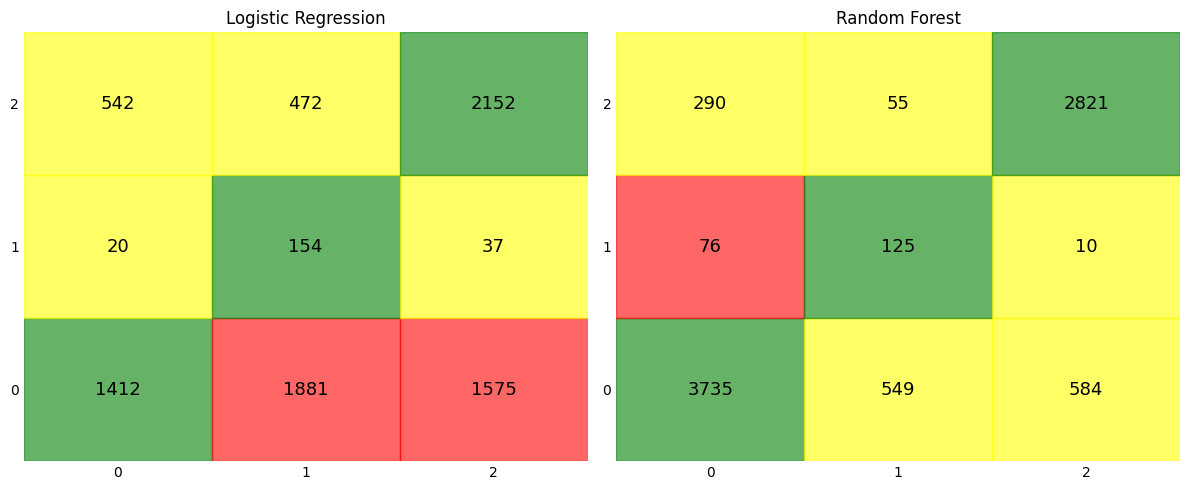

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_custom(cm, title, ax):
    cm = cm.astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ratio = cm_norm[i, j]

            if i == j:
                color = 'green'
            elif ratio < 0.2:
                color = 'yellow'
            else:
                color = 'red'

            rect = plt.Rectangle((j, i), 1, 1, color=color, alpha=0.6)
            ax.add_patch(rect)

            value = int(cm[i, j])
            ax.text(j + 0.5, i + 0.5, str(value),
                    ha='center', va='center', fontsize=13)

    ax.set_xlim(0, cm.shape[1])
    ax.set_ylim(0, cm.shape[0])

    ax.set_xticks(np.arange(cm.shape[1]) + 0.5)
    ax.set_yticks(np.arange(cm.shape[0]) + 0.5)

    ax.set_xticklabels(range(cm.shape[1]))
    ax.set_yticklabels(range(cm.shape[0]))

    ax.set_title(title)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0)
    


# ===== ÁP DỤNG =====
cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

plot_confusion_matrix_custom(cm_log, "Logistic Regression", axes[0])
plot_confusion_matrix_custom(cm_rf, "Random Forest", axes[1])
plt.tight_layout()
plt.show()

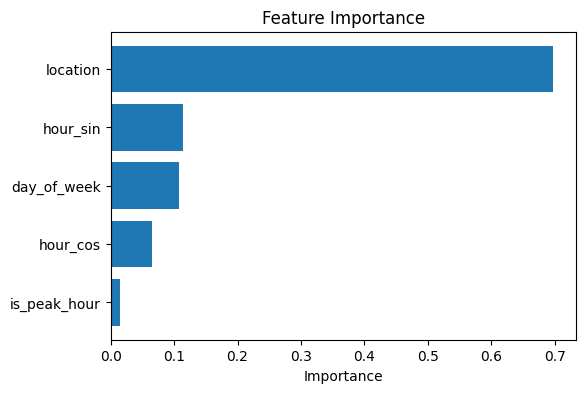

In [14]:
importances = rf_model.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(6,4))
plt.barh(np.array(features)[indices], importances[indices])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

### Conclusion
1. Confusion Matrix

The Confusion matrix is ​​normalized row by row, so the values ​​represent the *percentage (%) of predictions in each actual class*.

* Logistic Regression has a high rate of incorrect predictions. In class 0, only about 23% are predicted correctly, with most being mistaken for class 1 and class 2. Class 1 has a very low rate of correct predictions, indicating that the model does not learn well in this group.

* Random Forest shows significant improvement with a higher rate of correct predictions, especially in class 2. However, the model still struggles with class 1.

Overall, Random Forest performs better than Logistic Regression.

2. Feature Importance

The feature importance chart shows:

* hour_sin is the most important variable
* day_of_week and hour_cos have a moderate influence
* is_peak_hour has a very low influence

This indicates that *time of day is the main factor influencing traffic*, not just peak hours.

## Model Evaluation

- Random Forest achieved higher accuracy than Logistic Regression.

- However, both models had average accuracy (~0.4 - 0.47) due to using only temporal features.

## Key Findings

- The most important feature: hour_sin → time of day has the greatest influence.

- day_of_week also has a significant influence.

- is_peak_hour has a lower impact than expected.

## Confusion Matrix Insights

- The model is able to identify rare traffic classes (traffic_level = 1).

- However, there is still confusion between traffic levels.

## Conclusion

- Time influences traffic but not enough for accurate prediction.

- Additional features such as location or speed need to be added to improve the model.